#AIM
1. To determine the wavelength of Balmer series in the visible region from hydrogen emission spectrum.
2. To determine the Rydberg constant.

# Apparatus
1. High Voltage Power Supply
2. Mercury/Hydrogen Discharge Tube with Lamp House
3. Adjustable Slit
4. CCD
5. Constant Deviation Spectrometer
6. Stand for Spectrometer

# Setup Diagram
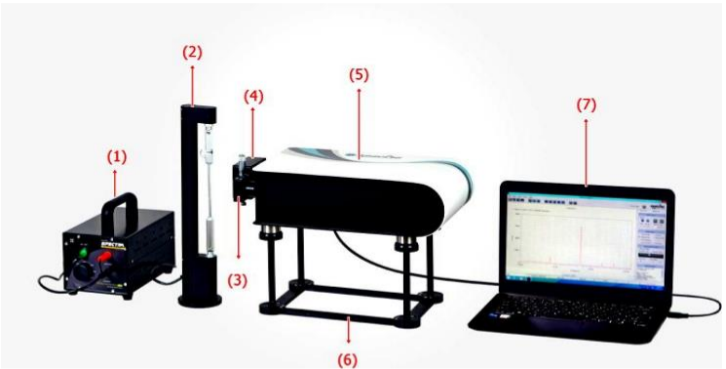

# Theory
Hydrogen atom in a discharge lamp emit a series of lines in the visible part of the spectrum. The formula to describe the wavelength of the Balmer lines is described by the formula:

$\frac{1}{λ} = R(\frac{1}{2^2}-\frac{1}{n^2})$

where $n = $the integers, 3, 4, 5... up to infinity and R is a constant, now called the Rydberg constant.
Johannes Robert Rydberg later found several series of spectra that would fit a more general relationship, similar to Balmer`s empirical formula. This general relation is known as Rydberg formula
and is given by

$\frac{1}{λ} = R(\frac{1}{n_i^2}-\frac{1}{n_f^2}); n_i>n_f$

# Spectrometer Calibration

Every element emits a characteristic spectrum of its own. To find the wavelength of light emitted usually
the spectrum of a standard source is measured and compared. The unknown wavelength is determined
by using Hartmann equations. The wavelength of the prominent lines in any spectrum of is studied by
using the Hartmann's formula:

$λ(d) = λ_0 + \frac{c}{d-d_0}$

where $c, λ_0, d_0$ are constants that must be determined experimentally.

This is done by
substituting the distances d of three known lines (in the mercury spectrum) from an arbitrary point and
their wavelengths λ in the above equation and solving the three equations. If we could find three lines
with scale readings $d_1, d_2$ and $d_3$ corresponding to known wavelengths $λ_1, λ_2$ and$ λ_3$ respectively, then
we can find Hartmann's constants using the following relations:

$A = \frac{ λ_2- λ_1 }{λ_3- λ_1}$


$B = \frac{d_2- d_1} {d_3- d_1}$

$λ0 = \frac{Aλ_3–Bλ_2}{A–B}$

$d0 = \frac{(Bd_3 ) – (A d_2 )}{ B – A }$

$C = \frac{(λ_2-λ_1)(d_0-d_1)(d_0-d_2)}{d_2-d_1}$


# Final Calculation
Using known values of the mercury spectrum, we substitute the pixel values of the hydrogen spectrum and find the Rydberg constant.


# Mercury Spectra

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

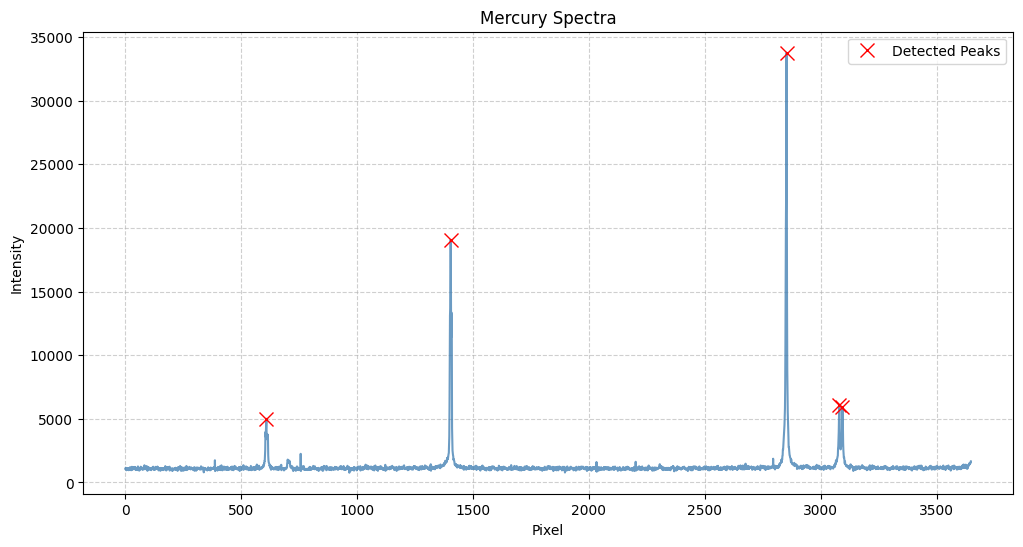

      Pixel  Raw Data
608     609      5005
1403   1404     19070
2852   2853     33764
3079   3080      6066
3093   3094      5913


In [ ]:
df = pd.read_csv('mercury.csv')
x = df['Pixel']
y = df['Raw Data']
peaks, properties = find_peaks(y, prominence=2000, distance=10)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, color='steelblue', alpha=0.8)
plt.plot(x.iloc[peaks], y.iloc[peaks], "x", label='Detected Peaks', color='red', markersize=10)
plt.title('Mercury Spectra')
plt.xlabel('Pixel')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print(df.iloc[peaks])

# Hydrogen Spectra

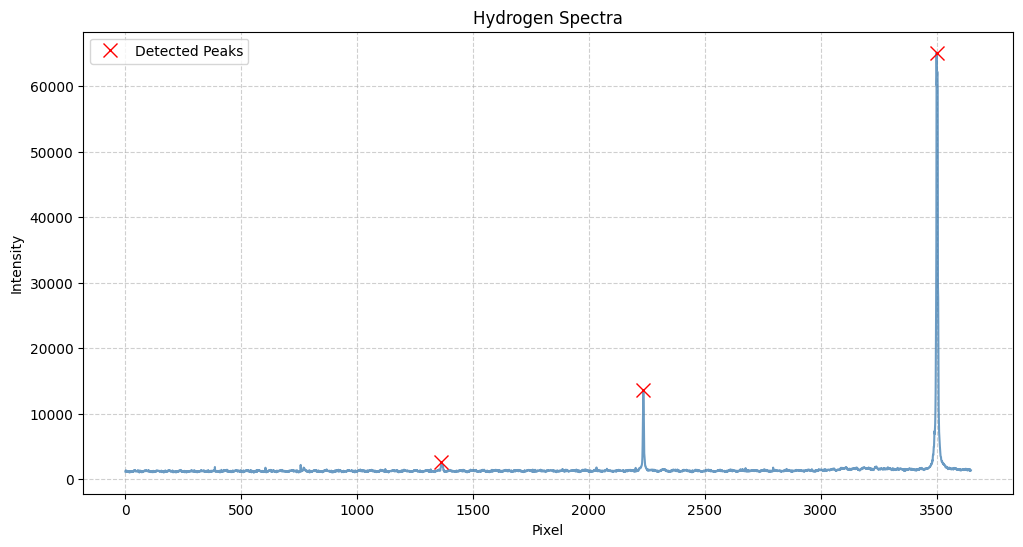

,Pixel,Raw Data
1363,1364,2578
2234,2235,13633
3499,3500,65122


In [ ]:
df = pd.read_csv('h2.csv')
x = df['Pixel']
y = df['Raw Data']
peaks, properties = find_peaks(y, prominence=1500, distance=10)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, color='steelblue', alpha=0.8)
plt.plot(x.iloc[peaks], y.iloc[peaks], "x", label='Detected Peaks', color='red', markersize=10)
plt.title('Hydrogen Spectra')
plt.xlabel('Pixel')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
display(df.iloc[peaks])

# Mercury as Calibration

In [ ]:
def compute_hartmann_constants(d1, d2, d3, l1, l2, l3):
  A = (l2 - l1) / (l3 - l1)
  B = (d2 - d1) / (d3 - d1)
  l0 = ((A * l3) - (B * l2)) / (A - B)
  d0 = ((B * d3) - (A * d2)) / (B - A)
  C = (l2 - l1) * (d0 - d1) * (d0 - d2) / (d2 - d1)
  return l0, d0, C

def hartmann_wavelength(d, l0, d0, C):
  return l0 + C / (d0 - d)

d1,d2,d3 = 609,1404,2853
l1,l2,l3 = 404.656,435.833,546.096 # wavelengths in nm

l0, d0, C = compute_hartmann_constants(d1, d2, d3, l1, l2, l3)
print(f"wavelength_0 = {l0:.4f} nm")
print(f"d0 = {d0:.4f}")
print(f"C  = {C:.4f}")

wavelength_0 = 254.2540 nm
d0 = 5239.1851
C  = 696388.9546


In [ ]:
# Wavelengths for Hydrogen
d_1,d_2,d_3 = 1364,2235,3500
lambda_1 = hartmann_wavelength(d_1, l0, d0, C)
lambda_2 = hartmann_wavelength(d_2, l0, d0, C)
lambda_3 = hartmann_wavelength(d_3, l0, d0, C)

print(f"lambda_1 = {lambda_1:.2f} nm")
print(f"lambda_2 = {lambda_2:.2f} nm")
print(f"lambda_3 = {lambda_3:.2f} nm")

lambda_1 = 433.96 nm
lambda_2 = 486.06 nm
lambda_3 = 654.67 nm


# Finding Rydberg Constant

In [ ]:
def rydberg_from_wavelength(lam, n):
  return 4*n**2/((n**2 - 4)*lam)

data = [{"lam": 654.67, "n": 3},{"lam": 486.06, "n": 4},{"lam": 433.96, "n": 5}]

R_values = []
for d in data:
  R = rydberg_from_wavelength(d["lam"], d["n"])
  R_values.append(R)
  print(f"lambda = {d['lam']:.2f} nm, n = {d['n']}, R = {R:.5f} 1/nm")

R_values = np.array(R_values)
R_avg = np.mean(R_values)
error = np.std(R_values)
print(f"Rydberg constant R = {R_avg:.5f} +- {error:.5f} 1/nm")
print(f"Rydberg constant R in m^-1 = {R_avg*1e9:.5f} +- {error*1e9:.5f} 1/m")

lambda = 654.67 nm, n = 3, R = 0.01100 1/nm
lambda = 486.06 nm, n = 4, R = 0.01097 1/nm
lambda = 433.96 nm, n = 5, R = 0.01097 1/nm
Rydberg constant R = 0.01098 +- 0.00001 1/nm
Rydberg constant R in m^-1 = 10981210.58000 +- 11808.60639 1/m


The first three Balmer lines are -
$$ \lambda_1 = 433.96 \, \text{nm}, \, \lambda_2 = 486.06 \, \text{nm},\, \lambda_3 = 654.67 \, \text{nm}$$
Therefore the Rydberg Constant Value is, $$R = 10981210.58000 \pm 11808.60639 \, m^{-1}$$